# Eksperimen Sistem Machine Learning - Predictive Maintenance

## 1. Perkenalan Dataset
Dataset ini digunakan untuk memprediksi kegagalan mesin (predictive maintenance) berdasarkan parameter teknis seperti suhu ruangan, suhu proses, kecepatan rotasi, torsi, dan keausan alat. Target utama adalah kolom `Target` yang bernilai:
- 0: Mesin Normal (No Failure)
- 1: Mesin Rusak (Failure)

## 2. Import Library

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

print("Library berhasil di-import!")

Library berhasil di-import!


## 3. Memuat Dataset

In [3]:
# Membaca dataset dari folder raw
path_data = "../namadataset_raw/predictive_maintenance.csv"
df = pd.read_csv(path_data)

# Menampilkan 5 baris pertama data untuk memeriksa strukturnya
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


## 4. Exploratory Data Analysis - EDA

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB

--- Statistik Deskriptif ---
               UDI  Air temperature [K]  Process temperature [K]  \
count  10000.00000         10000.000000             1000

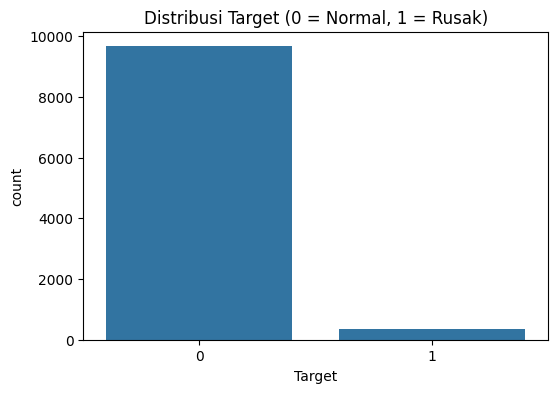

In [4]:
# 1. Memeriksa informasi tipe data dan missing value
print("--- Informasi Dataset ---")
df.info()

# 2. Memeriksa statistik deskriptif data numerik
print("\n--- Statistik Deskriptif ---")
print(df.describe())

# 3. Memeriksa jumlah data kosong (Missing Values)
print("\n--- Mengecek Missing Values ---")
print(df.isnull().sum())

# 4. Memeriksa distribusi kelas pada target (Imbalance check)
print("\n--- Distribusi Target ---")
print(df['Target'].value_counts())

# 5. Visualisasi sederhana distribusi target
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Target')
plt.title('Distribusi Target (0 = Normal, 1 = Rusak)')
plt.show()

## 5. Data Preprocessing

In [5]:
# Copy dataframe agar data asli tidak rusak
df_clean = df.copy()

# 1. Menghapus data duplikat jika ada
df_clean = df_clean.drop_duplicates()

# 2. Dropping kolom identitas yang tidak bernilai prediktif (UDI, Product ID, dan Failure Type)
# Kolom 'Failure Type' dihapus karena kita hanya fokus pada klasifikasi biner 'Target'
df_clean = df_clean.drop(columns=['UDI', 'Product ID', 'Failure Type'])

# 3. Encoding Data Kategorikal (Kolom 'Type' yang berisi tipe mesin L, M, H)
le = LabelEncoder()
df_clean['Type'] = le.fit_transform(df_clean['Type'])

# 4. Normalisasi/Standarisasi Fitur Numerik
scaler = StandardScaler()
fitur_numerik = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
df_clean[fitur_numerik] = scaler.fit_transform(df_clean[fitur_numerik])

# 5. Membuat folder output jika belum ada
output_dir = "namadataset_preprocessing"
os.makedirs(output_dir, exist_ok=True)

# 6. Menyimpan data hasil preprocessing ke format CSV
output_path = os.path.join(output_dir, "predictive_maintenance_clean.csv")
df_clean.to_csv(output_path, index=False)

print ("Data preprocessing selesai dan disimpan di: {output_path}")
df_clean.head()

Data preprocessing selesai dan disimpan di: {output_path}


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,2,-0.952389,-0.947360,0.068185,0.282200,-1.695984,0
1,1,-0.902393,-0.879959,-0.729472,0.633308,-1.648852,0
2,1,-0.952389,-1.014761,-0.227450,0.944290,-1.617430,0
3,1,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009,0
4,1,-0.902393,-0.879959,-0.729472,0.001313,-1.554588,0
